In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [3]:
#i) Match won by Maximum Margin of Runs
max_runs=matches[matches['win_by_runs']==matches['win_by_runs'].max()]
max_runs[['season','team1','team2','winner','win_by_runs']]

#Insight:
# a. This match had the highest run difference, meaning it was a one-sided match
# b.Such matches may reduce audience thrill but increase team dominance reputation

,season,team1,team2,winner,win_by_runs
43,2017,Mumbai Indians,Delhi Daredevils,Mumbai Indians,146


In [6]:
#ii) Match won by Maximum Wickets
max_wickets=matches[matches['win_by_wickets']==matches['win_by_wickets'].max()]
max_wickets[['season','team1','team2','winner','win_by_wickets']]
#Insights:
# a. Winning by 10 wickets usually shows complete dominance
# b. These matches indicate strong chasing ability

,season,team1,team2,winner,win_by_wickets
2,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,10
34,2017,Delhi Daredevils,Kings XI Punjab,Kings XI Punjab,10
71,2008,Mumbai Indians,Deccan Chargers,Deccan Chargers,10
119,2009,Kings XI Punjab,Delhi Daredevils,Delhi Daredevils,10
183,2010,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,10
298,2011,Mumbai Indians,Rajasthan Royals,Rajasthan Royals,10
376,2012,Rajasthan Royals,Mumbai Indians,Mumbai Indians,10
390,2013,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,10
542,2015,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,10
590,2016,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,10


In [7]:
# 3. Match won by minimum margin of runs

min_runs=matches[matches['win_by_runs']>0]
min_runs=min_runs[min_runs['win_by_runs']==min_runs['win_by_runs'].min()]
min_runs[['season','team1','team2','winner','win_by_runs']]

# Insights
# a.These matches were extremely close.
# b.Close matches increase audience engagement.

,season,team1,team2,winner,win_by_runs
58,2017,Mumbai Indians,Rising Pune Supergiant,Mumbai Indians,1
105,2008,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,1
163,2009,Kings XI Punjab,Deccan Chargers,Kings XI Punjab,1
344,2012,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,1
350,2012,Mumbai Indians,Pune Warriors,Mumbai Indians,1
518,2015,Chennai Super Kings,Delhi Daredevils,Chennai Super Kings,1
598,2016,Gujarat Lions,Delhi Daredevils,Gujarat Lions,1
614,2016,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,1
734,2019,Royal Challengers Bangalore,Chennai Super Kings,Royal Challengers Bangalore,1
755,2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,1


In [8]:
# 4. Match won by minimum wickets

min_wickets=matches[matches['win_by_wickets']>0]
min_wickets=min_wickets[min_wickets['win_by_wickets']==min_wickets['win_by_wickets'].min()]
min_wickets[['season','team1','team2','winner','win_by_wickets']]
# Insights:
# a.Winning by 1 wicket shows high pressure situations
# b.Such matches are highly thrilling.

,season,team1,team2,winner,win_by_wickets
559,2015,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders,1
636,2018,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,1
642,2018,Mumbai Indians,Sunrisers Hyderabad,Sunrisers Hyderabad,1


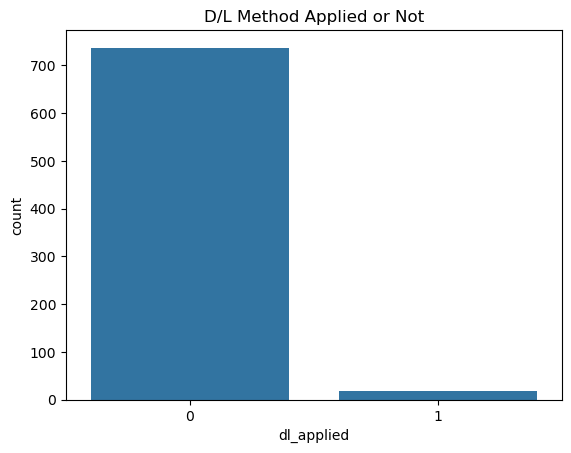

In [9]:
# 5. Matches where D/L method was and wasn't applied

matches['dl_applied'].value_counts()
sns.countplot(x='dl_applied',data=matches)
plt.title("D/L Method Applied or Not")
plt.show()
#Insights
# a. Most matches were normal
# b.Few matches used D/L(rain affected)

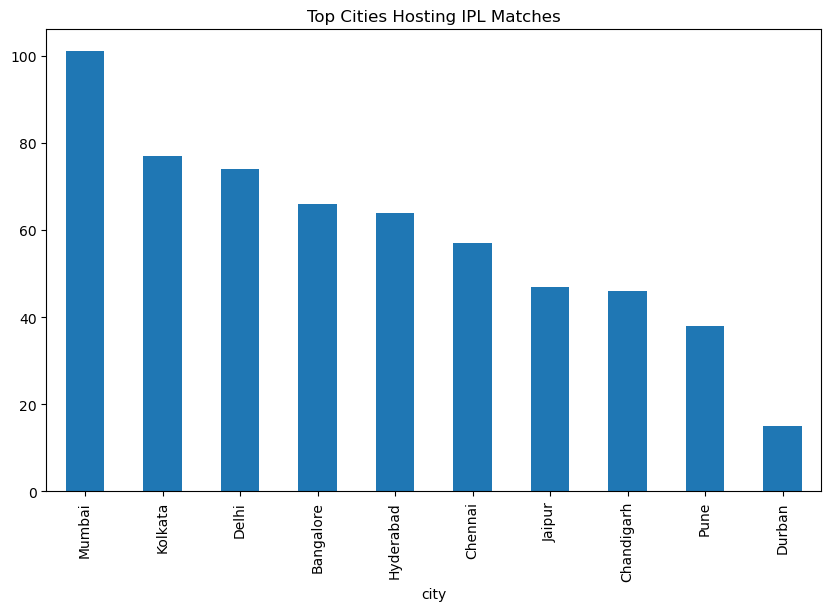

In [10]:
# 6. No. of matches held in each city

city_matches=matches['city'].value_counts()

plt.figure(figsize=(10,6))
city_matches.head(10).plot(kind='bar')
plt.title("Top Cities Hosting IPL Matches")
plt.show()
# Insights:
# a.Cities like, Mumbai, Kolkata, Chennai, host more cities
# b.Popular cities generate higher crowd engagement

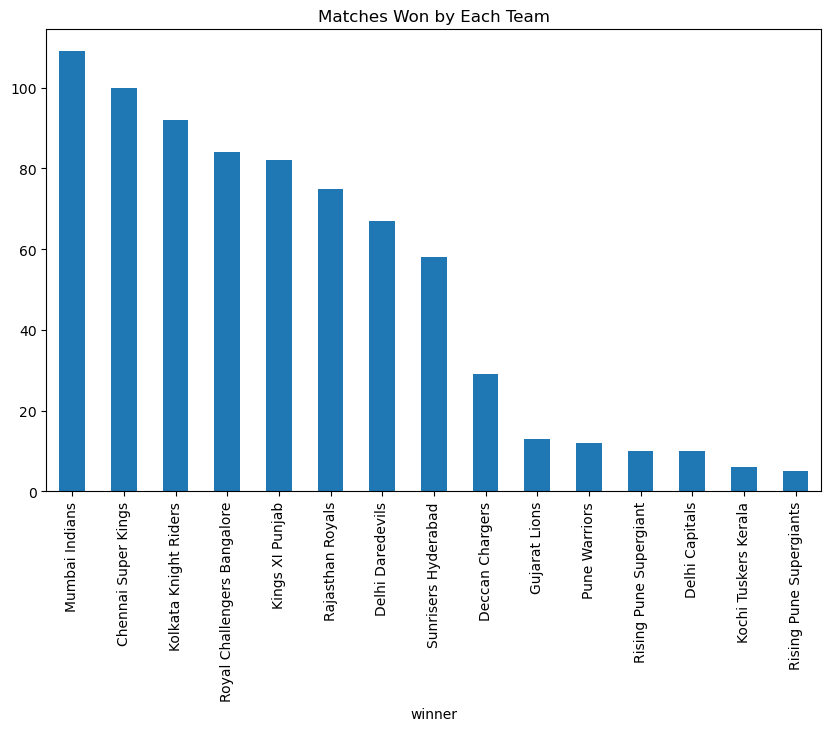

In [11]:
# 7. No. of matches won by each team

team_wins=matches['winner'].value_counts()

plt.figure(figsize=(10,6))
team_wins.plot(kind='bar')
plt.title("Matches Won by Each Team")
plt.show() 
# Insights:
# a.Teams like Mumbai Indians and Chennai Super Kings usually dominate.
# b.These teams have strong fan bases

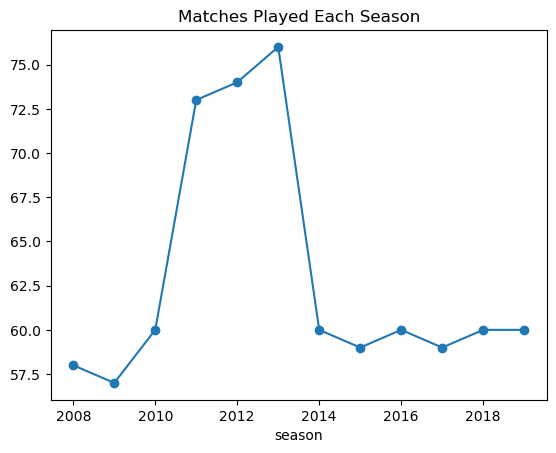

In [12]:
# 8. No. of matches held every season

season_matches=matches['season'].value_counts().sort_index()

season_matches.plot(kind='line',marker='o')
plt.title("Matches Played Each Season")
plt.show()
# Insights:
# a.Number of matches increased after adding new teams.
# b.Expansion increased league popularity.

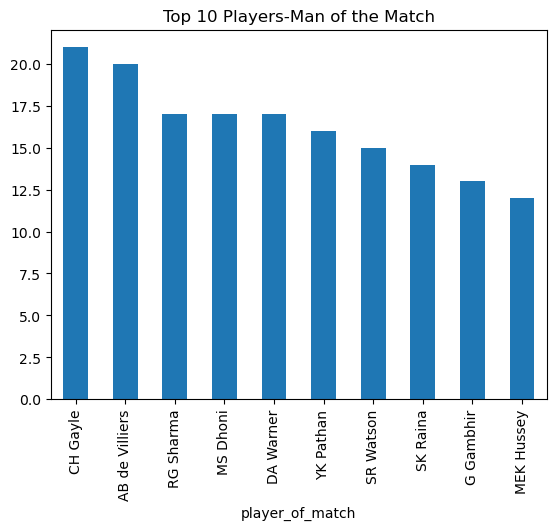

In [13]:
# 9. Top 10 Players(MOM awards)

mom=matches['player_of_match'].value_counts().head(10)

mom.plot(kind='bar')
plt.title("Top 10 Players-Man of the Match")
plt.show()
# Insight:
# a.Player with more MOM awards are high-impact performers.
# b.They contribute significantly to match results.

In [14]:
# 10. Does winning toss mean winning match?

toss_match=matches[matches['toss_winner']==matches['winner']]
percentage=(len(toss_match)/len(matches))*100
print(percentage)
# Insight:
# a.If percentage~50-55%, toss has slight advantage.
# b.Skill matters more than toss.

51.98412698412699


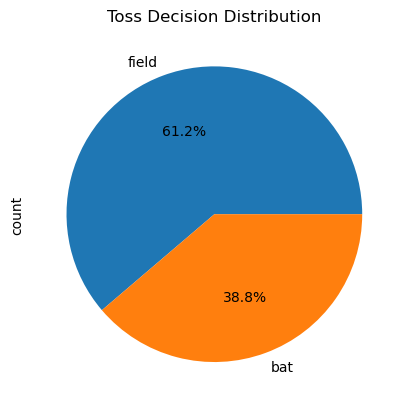

In [15]:
# 11. Toss Decision 

matches['toss_decision'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("Toss Decision Distribution")
plt.show()
# Insight:
# a.Most Captains prefer fielding first.
# b.Chasing is considered safer in T20.

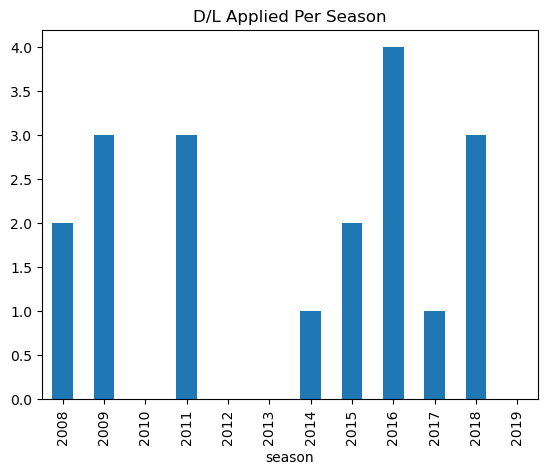

In [16]:
# 12. D/L method per season

dl_season=matches.groupby('season')['dl_applied'].sum()
dl_season.plot(kind='bar')
plt.title("D/L Applied Per Season")
plt.show()


In [17]:
# 13. Different match results

matches['result'].value_counts()
# Insight:
# a.Most matches are normal.
# b.Few ties and no result.

result
normal       743
tie            9
no result      4
Name: count, dtype: int64

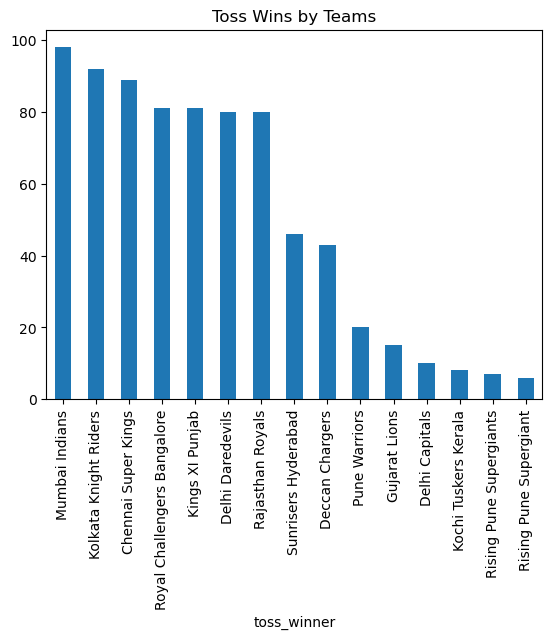

In [18]:
# 14. How many times did a team win toss?

matches['toss_winner'].value_counts().plot(kind='bar')
plt.title("Toss Wins by Teams")
plt.show()

In [19]:
# 15. Best venue for defending & chasing

defending=matches[matches['win_by_runs']>0]['venue'].value_counts().head(5)
chasing=matches[matches['win_by_wickets']>0]['venue'].value_counts().head(5)
print(defending)
print(chasing)
# Insight:
# a.Some stadium favor batting first.
# b.Some favor chasing due to pitch conditions.

venue
Wankhede Stadium                   35
Feroz Shah Kotla                   33
Eden Gardens                       32
MA Chidambaram Stadium, Chepauk    30
M Chinnaswamy Stadium              30
Name: count, dtype: int64
venue
Eden Gardens              45
M Chinnaswamy Stadium     40
Wankhede Stadium          37
Feroz Shah Kotla          33
Sawai Mansingh Stadium    32
Name: count, dtype: int64


In [20]:
# 16. Best Defending & Chasing teams

best_defending = matches[matches['win_by_runs'] > 0]['winner'].value_counts().head()
best_chasing = matches[matches['win_by_wickets'] > 0]['winner'].value_counts().head()
print(best_defending)
print(best_chasing)

winner
Mumbai Indians                 57
Chennai Super Kings            52
Kings XI Punjab                38
Kolkata Knight Riders          36
Royal Challengers Bangalore    35
Name: count, dtype: int64
winner
Kolkata Knight Riders          56
Mumbai Indians                 50
Royal Challengers Bangalore    48
Chennai Super Kings            48
Rajasthan Royals               46
Name: count, dtype: int64


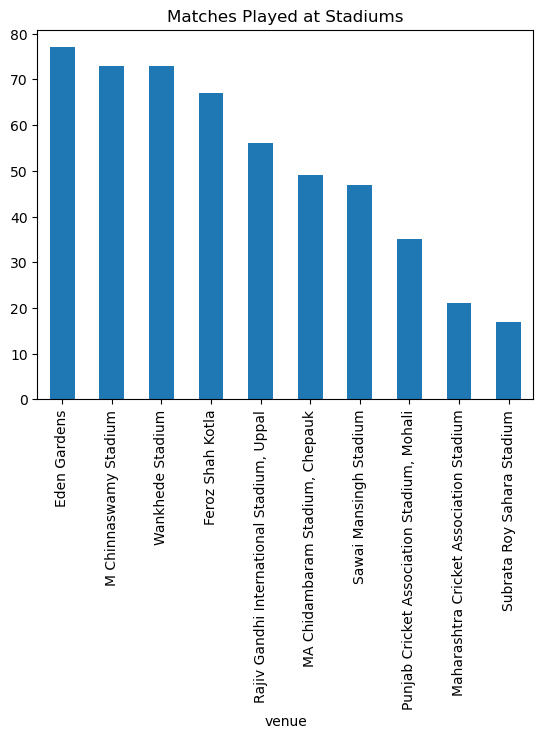

In [21]:
# 17. Matches played in different stadiums

matches['venue'].value_counts().head(10).plot(kind='bar')
plt.title("Matches Played at Stadiums")
plt.show()